# Compare experiment results: where cascade and multi_call disagree

Loads a `cascade_benchmark_results_*.csv` produced by `python -m cascade_prompting`, lines up every condition's answer to the same question, and surfaces the questions where two chosen conditions — by default `cascade` and `multi_call` — differ the most, with the full draft/fact-check/final trace for each one.

Install the extra deps this notebook needs (not required to run the benchmark itself):
```bash
uv pip install -e ".[notebook]"
```

In [1]:
from __future__ import annotations

import glob
from ast import literal_eval
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 140)
%matplotlib inline

## Load results

Picks the most recently modified `cascade_benchmark_results_*.csv` in the repo root (skipping the `_summary`/`_significance` companion files). Set `RESULTS_PATH` explicitly below if you want a specific run instead.

In [2]:
REPO_ROOT = Path.cwd()
if not list(REPO_ROOT.glob("cascade_benchmark_results_*.csv")) and (REPO_ROOT / "..").exists():
    REPO_ROOT = REPO_ROOT.parent  # allow running from notebooks/ too

candidates = [
    p for p in REPO_ROOT.glob("cascade_benchmark_results_*.csv")
    if "_summary" not in p.name and "_significance" not in p.name
]
RESULTS_PATH = max(candidates, key=lambda p: p.stat().st_mtime)  # override manually if needed
print(f"Loading {RESULTS_PATH}")

raw = pd.read_csv(RESULTS_PATH)
if "context_sentences" in raw.columns:
    raw["context_sentences"] = raw["context_sentences"].apply(literal_eval)
print(f"{len(raw)} rows, {raw['condition'].nunique()} conditions: {sorted(raw['condition'].unique())}")
raw.groupby("condition").size()

Loading /Users/michalnasternak/Code/cascade_prompting/cascade_benchmark_results_2026-08-21_gpt-oss-120b.csv
155 rows, 4 conditions: ['baseline', 'cascade', 'multi_call', 'multi_call_full_context']


condition
baseline                   39
cascade                    38
multi_call                 39
multi_call_full_context    39
dtype: int64

## Pick the two conditions to compare

Defaults to `cascade` vs. `multi_call`, matching the pairing this notebook is named for. Change `CONDITION_A` / `CONDITION_B` to compare any other pair in the run (e.g. `multi_call` vs. `multi_call_full_context`).

In [3]:
CONDITION_A = "cascade"
CONDITION_B = "multi_call"

a = raw[raw.condition == CONDITION_A].set_index("example_idx")
b = raw[raw.condition == CONDITION_B].set_index("example_idx")
shared_idx = a.index.intersection(b.index)
# Guard against the resume/question-mismatch edge case: only compare rows where
# both conditions actually answered the *same* question at this example_idx.
shared_idx = [i for i in shared_idx if a.loc[i, "question"] == b.loc[i, "question"]]
a, b = a.loc[shared_idx], b.loc[shared_idx]
print(f"{len(shared_idx)} questions answered by both {CONDITION_A!r} and {CONDITION_B!r}")

38 questions answered by both 'cascade' and 'multi_call'


## Build the paired comparison frame

One row per shared question, with each metric side by side plus a `*_gap` column (`B - A`, so positive means condition B scored higher).

In [4]:
METRICS = ["hotpot_em", "hotpot_f1", "hotpot_precision", "hotpot_recall", "answer_accuracy"]

paired = pd.DataFrame({
    "example_idx": shared_idx,
    "question": a["question"].values,
    "gold_answer": a["gold_answer"].values,
    f"{CONDITION_A}_answer": a["predicted_answer"].values,
    f"{CONDITION_B}_answer": b["predicted_answer"].values,
}).set_index("example_idx")

for m in METRICS:
    paired[f"{CONDITION_A}_{m}"] = a[m].values
    paired[f"{CONDITION_B}_{m}"] = b[m].values
    paired[f"{m}_gap"] = paired[f"{CONDITION_B}_{m}"] - paired[f"{CONDITION_A}_{m}"]

paired.head()

,question,gold_answer,cascade_answer,multi_call_answer,cascade_hotpot_em,multi_call_hotpot_em,hotpot_em_gap,cascade_hotpot_f1,multi_call_hotpot_f1,hotpot_f1_gap,cascade_hotpot_precision,multi_call_hotpot_precision,hotpot_precision_gap,cascade_hotpot_recall,multi_call_hotpot_recall,hotpot_recall_gap,cascade_answer_accuracy,multi_call_answer_accuracy,answer_accuracy_gap
example_idx,,,,,,,,,,,,,,,,,,,
0,Were Scott Derrickson and Ed Wood of the same nationality?,yes,Yes,Yes,1.0,1.0,0.0,1.00,1.000000,0.000000,1.0,1.0,0.0,1.0,1.0,0.0,1.000000,1.000000,0.000000
1,What government position was held by the woman who portrayed Corliss Archer in the film Kiss and Tell?,Chief of Protocol,United States ambassador to Ghana,Chief of Protocol of the United States,0.0,0.0,0.0,0.00,0.666667,0.666667,0.0,0.5,0.5,0.0,1.0,1.0,0.253502,0.888173,0.634671
2,"What science fantasy young adult series, told in first person, has a set of companion books narrating the stories of...",Animorphs,Animorphs,Animorphs,1.0,1.0,0.0,1.00,1.000000,0.000000,1.0,1.0,0.0,1.0,1.0,0.0,1.000000,1.000000,0.000000
3,Are the Laleli Mosque and Esma Sultan Mansion located in the same neighborhood?,no,No,No,1.0,1.0,0.0,1.00,1.000000,0.000000,1.0,1.0,0.0,1.0,1.0,0.0,1.000000,1.000000,0.000000
4,"The director of the romantic comedy ""Big Stone Gap"" is based in what New York city?","Greenwich Village, New York City",New York City,New York City,0.0,0.0,0.0,0.75,0.750000,0.000000,1.0,1.0,0.0,0.6,0.6,0.0,0.653998,0.653998,0.000000


## Where do they disagree on exact match?

The cleanest definition of "a big gap": one condition got the exact-match string right, the other didn't. This is exactly the discordant-pair set McNemar's test (see `cascade_prompting/metrics/significance.py`) is built on — the counts below should match the `mean_a`/`mean_b` columns for this pair in the run's own `*_significance.csv`.

In [5]:
em_a, em_b = paired[f"{CONDITION_A}_hotpot_em"], paired[f"{CONDITION_B}_hotpot_em"]
a_right_b_wrong = paired[(em_a == 1) & (em_b == 0)]
b_right_a_wrong = paired[(em_a == 0) & (em_b == 1)]
both_right = int(((em_a == 1) & (em_b == 1)).sum())
both_wrong = int(((em_a == 0) & (em_b == 0)).sum())

print(f"{CONDITION_A} right, {CONDITION_B} wrong: {len(a_right_b_wrong)}")
print(f"{CONDITION_B} right, {CONDITION_A} wrong: {len(b_right_a_wrong)}")
print(f"both right: {both_right}    both wrong: {both_wrong}")

cascade right, multi_call wrong: 2
multi_call right, cascade wrong: 3
both right: 19    both wrong: 14


## Biggest gaps within the disagreement set

Among the EM-discordant questions above, rank by how large the `hotpot_f1` gap also is — an EM flip where F1 also moved a lot is a cleaner, less ambiguous case than one where F1 barely changed (e.g. a near-miss on wording). Set `TOP_N` to see more or fewer.

In [6]:
TOP_N = 10

b_wins = b_right_a_wrong.reindex(
    b_right_a_wrong["hotpot_f1_gap"].abs().sort_values(ascending=False).index
).head(TOP_N)
a_wins = a_right_b_wrong.reindex(
    a_right_b_wrong["hotpot_f1_gap"].abs().sort_values(ascending=False).index
).head(TOP_N)

display_cols = [
    "question", "gold_answer", f"{CONDITION_A}_answer", f"{CONDITION_B}_answer",
    "hotpot_em_gap", "hotpot_f1_gap", "answer_accuracy_gap",
]
print(f"Top {TOP_N} questions where {CONDITION_B} wins big:")
b_wins[display_cols]

Top 10 questions where multi_call wins big:


,question,gold_answer,cascade_answer,multi_call_answer,hotpot_em_gap,hotpot_f1_gap,answer_accuracy_gap
example_idx,,,,,,,
28,Kaiser Ventures corporation was founded by an American industrialist who became known as the father of modern Americ...,Henry J. Kaiser,Yes,Henry J. Kaiser,1.0,1.000000,0.910406
33,Are Freakonomics and In the Realm of the Hackers both American documentaries?,no,Freakonomics: The Movie is a 2010 American documentary film. In The Realm of the Hackers is a 2003 Australian docume...,No,1.0,1.000000,0.917326
8,"Who is older, Annie Morton or Terry Richardson?",Terry Richardson,"Annie Morton (born October 8, 1970) ... Terry Richardson (born August 14, 1965) ...",Terry Richardson,1.0,0.714286,0.436783


In [7]:
print(f"Top {TOP_N} questions where {CONDITION_A} wins big:")
a_wins[display_cols]

Top 10 questions where cascade wins big:


,question,gold_answer,cascade_answer,multi_call_answer,hotpot_em_gap,hotpot_f1_gap,answer_accuracy_gap
example_idx,,,,,,,
30,"When was Poison's album ""Shut Up, Make Love"" released?",2000,2000,"March 14, 2000",-1.0,-0.500000,-0.382466
24,What was the father of Kasper Schmeichel voted to be by the IFFHS in 1992?,World's Best Goalkeeper,World's Best Goalkeeper,World’s Best Goalkeeper,-1.0,-0.333333,-0.002465


## Full trace for a given question

`show_trace(idx)` prints the question, gold answer, and every layer both conditions produced — `draft`/`fact_checked`/`final` data *and* reasoning where present — plus the metrics side by side. This is the same information the raw CSV's `layer_*_data` / `layer_*_reasoning` columns carry, just formatted for reading instead of spreadsheet rows.

In [8]:
LAYER_NAMES = ("draft", "fact_checked", "final")

def _print_condition_trace(df: pd.DataFrame, idx: int, condition: str) -> None:
    row = df.loc[idx]
    print(f"--- {condition} " + "-" * (60 - len(condition)))
    for layer in LAYER_NAMES:
        data_col, reasoning_col = f"layer_{layer}_data", f"layer_{layer}_reasoning"
        if data_col not in row or pd.isna(row[data_col]):
            continue
        print(f"  [{layer}]")
        if reasoning_col in row and pd.notna(row.get(reasoning_col)):
            print(f"    reasoning: {row[reasoning_col]}")
        print(f"    data:      {row[data_col]}")
    print(f"  final answer: {row['predicted_answer']!r}")
    print(
        f"  em={row['hotpot_em']:.0f} f1={row['hotpot_f1']:.2f} "
        f"recall={row['hotpot_recall']:.2f} answer_accuracy={row['answer_accuracy']:.3f} "
        f"tokens={row['total_tokens']:.0f} latency={row['latency_s']:.1f}s"
    )

def show_trace(idx: int, show_context: bool = False) -> None:
    print(f"question ({idx}): {a.loc[idx, 'question']}")
    print(f"gold answer:  {a.loc[idx, 'gold_answer']}")
    if show_context:
        print("context:")
        for sentence in a.loc[idx, "context_sentences"]:
            print(f"  - {sentence}")
    print()
    _print_condition_trace(a, idx, CONDITION_A)
    print()
    _print_condition_trace(b, idx, CONDITION_B)

### Traces for the biggest condition-B-wins-big questions (`multi_call` by default)

In [9]:
for idx in b_wins.index[:3]:
    show_trace(idx)
    print("=" * 100)

question (28): Kaiser Ventures corporation was founded by an American industrialist who became known as the father of modern American shipbuilding?
gold answer:  Henry J. Kaiser

--- cascade -----------------------------------------------------
  [draft]
    reasoning: Kaiser Ventures corporation was founded by Henry J. Kaiser, who is described in the documents as an American industrialist known as the father of modern American shipbuilding. Therefore, the statement is true.
    data:      Kaiser Ventures was founded by Henry J. Kaiser. Henry J. Kaiser was an American industrialist who became known as the father of modern American shipbuilding.
  [fact_checked]
    reasoning: Both claims are directly supported by the provided documents.
    data:      Kaiser Ventures was founded by Henry J. Kaiser. Henry J. Kaiser was known as the father of modern American shipbuilding.
  [final]
    reasoning: The question asks if the founder of Kaiser Ventures was the industrialist known as the fathe

### Traces for the biggest condition-A-wins-big questions (`cascade` by default)

In [10]:
for idx in a_wins.index[:3]:
    show_trace(idx)
    print("=" * 100)

question (30): When was Poison's album "Shut Up, Make Love" released?
gold answer:  2000

--- cascade -----------------------------------------------------
  [draft]
    reasoning: The document states that "Shut Up, Make Love" is a song by Poison released in 2000. No album with that title is mentioned; the related album "Crack a Smile...and More!" was released on March 14, 2000. Therefore, the release year associated with "Shut Up, Make Love" is 2000.
    data:      2000
  [fact_checked]
    reasoning: The answer "2000" is directly supported by the document stating the song was released in 2000. No claim about an album title is made, avoiding unsupported statements.
    data:      2000
  [final]
    reasoning: The question asks for the release date of Poison's album "Shut Up, Make Love". The documents only provide a release year for the song, which is 2000. This is the most accurate answer based on the provided information.
    data:      2000
  final answer: '2000'
  em=1 f1=1.00 reca

## Gaps beyond exact match

EM-discordant pairs are the sharpest cases, but not the only ones worth seeing — two answers can both be "wrong" (or both "right") by exact match while still differing a lot in how close they are. This ranks *every* shared question, regardless of the EM outcome, by the size of a chosen continuous metric's gap.

In [11]:
GAP_METRIC = "answer_accuracy"  # try "hotpot_f1" or "hotpot_recall" too

biggest_gaps = paired.reindex(
    paired[f"{GAP_METRIC}_gap"].abs().sort_values(ascending=False).index
).head(TOP_N)
biggest_gaps[display_cols + [f"{GAP_METRIC}_gap"]]

,question,gold_answer,cascade_answer,multi_call_answer,hotpot_em_gap,hotpot_f1_gap,answer_accuracy_gap,answer_accuracy_gap
example_idx,,,,,,,,
33,Are Freakonomics and In the Realm of the Hackers both American documentaries?,no,Freakonomics: The Movie is a 2010 American documentary film. In The Realm of the Hackers is a 2003 Australian docume...,No,1.0,1.000000,0.917326,0.917326
28,Kaiser Ventures corporation was founded by an American industrialist who became known as the father of modern Americ...,Henry J. Kaiser,Yes,Henry J. Kaiser,1.0,1.000000,0.910406,0.910406
1,What government position was held by the woman who portrayed Corliss Archer in the film Kiss and Tell?,Chief of Protocol,United States ambassador to Ghana,Chief of Protocol of the United States,0.0,0.666667,0.634671,0.634671
8,"Who is older, Annie Morton or Terry Richardson?",Terry Richardson,"Annie Morton (born October 8, 1970) ... Terry Richardson (born August 14, 1965) ...",Terry Richardson,1.0,0.714286,0.436783,0.436783
30,"When was Poison's album ""Shut Up, Make Love"" released?",2000,2000,"March 14, 2000",-1.0,-0.500000,-0.382466,-0.382466
19,"Which writer was from England, Henry Roth or Robert Erskine Childers?",Robert Erskine Childers DSC,Robert Erkin Childers,Robert Erskine Childers,0.0,0.285714,0.279437,0.279437
15,Brown State Fishing Lake is in a country that has a population of how many inhabitants ?,"9,984",Not provided,332 million,0.0,0.000000,0.125875,0.125875
24,What was the father of Kasper Schmeichel voted to be by the IFFHS in 1992?,World's Best Goalkeeper,World's Best Goalkeeper,World’s Best Goalkeeper,-1.0,-0.333333,-0.002465,-0.002465
32,Which French ace pilot and adventurer fly L'Oiseau Blanc,Charles Eugène,Charles Nungesser,Charles Nungesser,0.0,0.000000,0.000000,0.000000


## Distribution of gaps across the whole run

Sanity-check the worked examples above against the overall shape: is a large gap rare and exceptional, or common? The vertical line at 0 marks "no difference"; the further the mass sits from it and the more asymmetric the distribution, the more the qualitative examples above are representative of a real pattern rather than a handful of outliers.

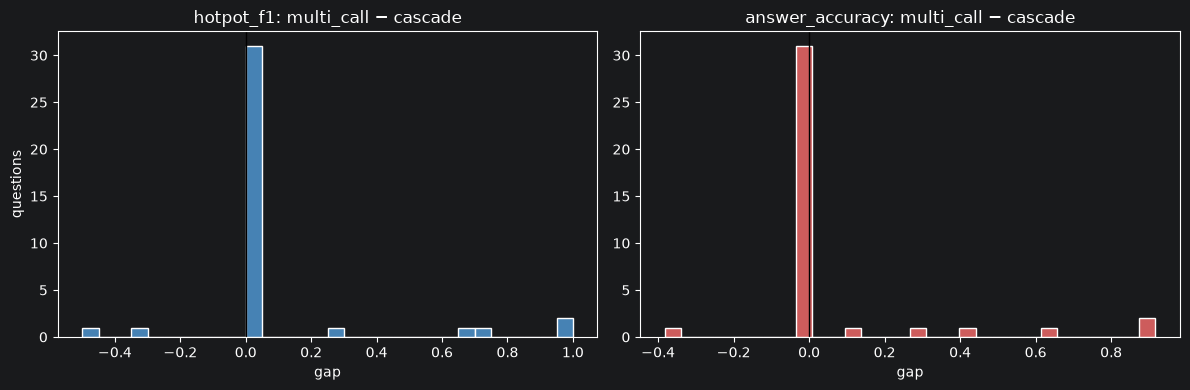

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(paired["hotpot_f1_gap"], bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title(f"hotpot_f1: {CONDITION_B} − {CONDITION_A}")
axes[0].set_xlabel("gap")
axes[0].set_ylabel("questions")

axes[1].hist(paired["answer_accuracy_gap"], bins=30, color="indianred", edgecolor="white")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title(f"answer_accuracy: {CONDITION_B} − {CONDITION_A}")
axes[1].set_xlabel("gap")

fig.tight_layout()
plt.show()

## Export the biggest-gap questions

Writes the top `TOP_N` questions from each direction (EM-discordant, ranked by F1 gap) to a CSV next to the source results file, for reading outside the notebook or handing to someone who just wants the list.

In [13]:
out_path = RESULTS_PATH.with_name(
    RESULTS_PATH.stem + f"_biggest_gaps_{CONDITION_A}_vs_{CONDITION_B}.csv"
)
pd.concat(
    [b_wins.assign(winner=CONDITION_B), a_wins.assign(winner=CONDITION_A)]
)[display_cols + ["winner"]].to_csv(out_path)
print(f"Wrote {out_path}")

Wrote /Users/michalnasternak/Code/cascade_prompting/cascade_benchmark_results_2026-08-21_gpt-oss-120b_biggest_gaps_cascade_vs_multi_call.csv
